# Sokoban Generator Dataset Sampling: Old vs New (Hierarchical)

This notebook visualizes **state -> subgoal** training pairs for two dataset-building strategies:

- **Old / current baseline** (`configs/offline_training/sokoban/sokoban_train_generator.yaml`):
  trajectory dataset + `subgoal_distance_interval: [8]` (sliding-window over solved trajectories)
- **New planned/recent idea** (`configs/offline_training/sokoban/sokoban_train_generator_signals.yaml`):
  `solve_attempts` experiences + hierarchical `k_offsets` targets (e.g. `k=8`, offsets `[-1, 1]`)

It also shows quick pair-count statistics so you can see how dense/sparse each signal is.


In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import statistics
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import display, Markdown

from carl.environment.sokoban.env import SokobanEnv
from carl.environment.sokoban.tokenizer import SokobanTokenizer
from carl.planners.base import Experience
from carl.solver.nodes import get_solving_path_data
from carl.utils.generator_targets import iter_state_pairs_sliding_window
from carl.utils.generator_targets import iter_state_pairs_k_offsets
from carl.utils.generator_targets import _subgoal_positions_with_k  # internal helper used for exact parity with training code


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'carl').exists():
            return p
    raise RuntimeError('Could not find repo root from current working directory.')

ROOT = find_repo_root()
OLD_CFG_PATH = ROOT / 'configs/offline_training/sokoban/sokoban_train_generator.yaml'
NEW_CFG_PATH = ROOT / 'configs/offline_training/sokoban/sokoban_train_generator_signals.yaml'

old_cfg = yaml.safe_load(OLD_CFG_PATH.read_text())
new_cfg = yaml.safe_load(NEW_CFG_PATH.read_text())

old_dm = old_cfg['algorithm']['datamodule']
new_dm = new_cfg['algorithm']['datamodule']

print('Repo root:', ROOT)
print('Old config:', OLD_CFG_PATH)
print('  dataset_path =', old_dm['dataset_path'])
print('  subgoal_distance_interval =', old_dm['subgoal_distance_interval'])
print('  num_of_trajectories =', old_dm['num_of_trajectories'])
print()
print('Signals config (new idea):', NEW_CFG_PATH)
print('  experiences_path =', new_dm.get('experiences_path'))
print('  generator_target_mode =', new_dm.get('generator_target_mode'))
print('  generator_k =', new_dm.get('generator_k'))
print('  generator_offsets =', new_dm.get('generator_offsets'))
print('  experiences_glob =', new_dm.get('experiences_glob'))


Repo root: /home/mtyrolski/dev/carl/CaRL
Old config: /home/mtyrolski/dev/carl/CaRL/configs/offline_training/sokoban/sokoban_train_generator.yaml
  dataset_path = ./rl-data/validation/sokoban/offline/12-12-4
  subgoal_distance_interval = [8]
  num_of_trajectories = 1000

Signals config (new idea): /home/mtyrolski/dev/carl/CaRL/configs/offline_training/sokoban/sokoban_train_generator_signals.yaml
  experiences_path = ./solve_attempts
  generator_target_mode = sliding_window
  generator_k = 8
  generator_offsets = [-1, 1]
  experiences_glob = solved_problems_*_12x12x4_batch_*.joblib


In [3]:
def make_sokoban_env() -> SokobanEnv:
    tok = SokobanTokenizer(
        cut_distance=150,
        type_of_value_training='regression',
        size_of_board=[12, 12],
        remove_border=False,
    )
    return SokobanEnv(tokenizer=tok, num_boxes=4)


def flatten_experiences(item: object, limit: int | None = None) -> list[Experience]:
    out: list[Experience] = []
    stack: list[object] = [item]
    while stack:
        cur = stack.pop()
        if isinstance(cur, Experience):
            out.append(cur)
            if limit is not None and len(out) >= limit:
                break
        elif isinstance(cur, list):
            stack.extend(cur)
    return out


def load_offline_trajectories(offline_dir: Path, max_trajectories: int = 100) -> dict[int, np.ndarray]:
    data: dict[int, np.ndarray] = {}
    for file in sorted(offline_dir.iterdir()):
        part = joblib.load(file)
        data.update(part)
        if len(data) >= max_trajectories:
            break
    items = list(data.items())[:max_trajectories]
    return dict(items)


def load_experiences(experiences_dir: Path, pattern: str, max_experiences: int = 200) -> list[Experience]:
    exps: list[Experience] = []
    for file in sorted(experiences_dir.glob(pattern)):
        exps.extend(flatten_experiences(joblib.load(file), limit=max_experiences - len(exps)))
        if len(exps) >= max_experiences:
            break
    return exps[:max_experiences]


def solved_experiences_with_nodes(experiences: list[Experience]) -> list[Experience]:
    out: list[Experience] = []
    for exp in experiences:
        if not getattr(exp.solution, 'solved', False):
            continue
        if exp.search_info.solving_node is None:
            continue
        out.append(exp)
    return out


def state_path_from_experience(exp: Experience, env: SokobanEnv):
    solving_node = exp.search_info.solving_node
    if solving_node is None or not exp.solution.solved:
        return None
    _, _, _, _, state_path = get_solving_path_data(solving_node, include_state_path=True, env=env)
    return state_path


def old_generator_pairs_from_trajectory(trajectory, distance_range=(8,)):
    rows = []
    traj_len = len(trajectory)
    for pos in range(traj_len - 1):
        for dist in distance_range:
            inner = min(dist, traj_len - 1 - pos)
            rows.append({
                'state': trajectory[pos],
                'subgoal': trajectory[pos + inner],
                'position': pos,
                'requested_dist': int(dist),
                'effective_dist': int(inner),
                'path_len': traj_len,
            })
            if pos + inner >= traj_len - 1:
                break
    return rows


def k_offset_pairs_from_experience(exp: Experience, env: SokobanEnv, k: int = 8, offsets=(-1, 1)):
    state_path = state_path_from_experience(exp, env)
    if not state_path:
        return [], None, []
    solving_node = exp.search_info.solving_node
    assert solving_node is not None
    subgoal_positions = _subgoal_positions_with_k(solving_node, exp.solution.subgoal_distance_path)

    rows = []
    for position, k_used in subgoal_positions:
        if k_used != k:
            continue
        for offset in offsets:
            start_idx = position - k + offset
            if 0 <= start_idx < position:
                rows.append({
                    'state': state_path[start_idx],
                    'subgoal': state_path[position],
                    'position': int(position),
                    'start_index': int(start_idx),
                    'offset': int(offset),
                    'k_used': int(k),
                    'path_len': len(state_path),
                })
    return rows, state_path, subgoal_positions


def plot_pair_rows(rows, env: SokobanEnv, title: str, n: int = 6, seed: int = 0):
    if not rows:
        raise ValueError('No rows to plot.')
    rnd = random.Random(seed)
    chosen = rows if len(rows) <= n else rnd.sample(rows, n)
    nrows = len(chosen)
    fig, axes = plt.subplots(nrows, 2, figsize=(8, 3.2 * nrows))
    if nrows == 1:
        axes = np.array([axes])
    fig.suptitle(title, fontsize=14)
    for r, (ax_l, ax_r) in zip(chosen, axes):
        ax_l.imshow(env._state_to_rgb(r['state']))
        ax_l.axis('off')
        left_title = f"state"
        if 'position' in r:
            left_title += f" t={r['position']}"
        if 'start_index' in r:
            left_title += f" idx={r['start_index']}"
        ax_l.set_title(left_title)

        ax_r.imshow(env._state_to_rgb(r['subgoal']))
        ax_r.axis('off')
        right_title = 'subgoal'
        if 'effective_dist' in r:
            right_title += f" (d_eff={r['effective_dist']})"
        if 'offset' in r:
            right_title += f" (k={r['k_used']}, off={r['offset']:+d})"
        ax_r.set_title(right_title)
    plt.tight_layout()
    return fig, chosen


def describe_rows(rows, keys=('position', 'requested_dist', 'effective_dist', 'start_index', 'offset', 'k_used')):
    printable = []
    for r in rows:
        printable.append({k: r[k] for k in keys if k in r})
    return printable


def summarize_counts(values):
    if not values:
        return {}
    return {
        'n': len(values),
        'min': int(min(values)),
        'mean': float(round(statistics.mean(values), 2)),
        'median': float(statistics.median(values)),
        'max': int(max(values)),
    }


In [4]:
env = make_sokoban_env()

offline_dir = ROOT / old_dm['dataset_path']
experiences_dir = ROOT / 'solve_attempts'

# Defaults picked to surface hierarchical k=8 examples reliably.
EXP_PATTERN = 'solved_problems_k841_12x12x4_batch_*.joblib'  # try also: k8, k84, k4
K = 8
OFFSETS = (-1, 1)
OLD_DISTANCE_RANGE = tuple(old_dm['subgoal_distance_interval'])

offline = load_offline_trajectories(offline_dir, max_trajectories=80)
raw_experiences = load_experiences(experiences_dir, EXP_PATTERN, max_experiences=240)
exps = solved_experiences_with_nodes(raw_experiences)

print('offline trajectories loaded:', len(offline))
print('raw experiences loaded:', len(raw_experiences))
print('solved experiences w/ solving_node:', len(exps))

# Quick k-used distribution (for hierarchical runs)
k_counter = Counter()
for exp in exps[:50]:
    _, _, subgoal_positions = k_offset_pairs_from_experience(exp, env, k=K, offsets=OFFSETS)
    for _, k_used in subgoal_positions:
        k_counter[k_used] += 1
print('k_used distribution on first 50 solved exps (including None):', k_counter.most_common(10))


Loading assets from package: carl.environment.sokoban
offline trajectories loaded: 80
raw experiences loaded: 240
solved experiences w/ solving_node: 217
k_used distribution on first 50 solved exps (including None): [(8, 341), (None, 50), (4, 15), (1, 4)]


## Old way: trajectory dataset (`sokoban_train_generator.yaml`)

This reproduces the **trajectory sliding-window** target generation used by the old generator training config.
With `subgoal_distance_interval: [8]`, each trajectory position contributes roughly one target (`t -> t+8`, clamped to final state near the end).


Selected trajectory key: 53001
Trajectory length: 140
Generated pairs (old sliding-window): 139
First 8 pair descriptors:
  {'position': 0, 'requested_dist': 8, 'effective_dist': 8}
  {'position': 1, 'requested_dist': 8, 'effective_dist': 8}
  {'position': 2, 'requested_dist': 8, 'effective_dist': 8}
  {'position': 3, 'requested_dist': 8, 'effective_dist': 8}
  {'position': 4, 'requested_dist': 8, 'effective_dist': 8}
  {'position': 5, 'requested_dist': 8, 'effective_dist': 8}
  {'position': 6, 'requested_dist': 8, 'effective_dist': 8}
  {'position': 7, 'requested_dist': 8, 'effective_dist': 8}


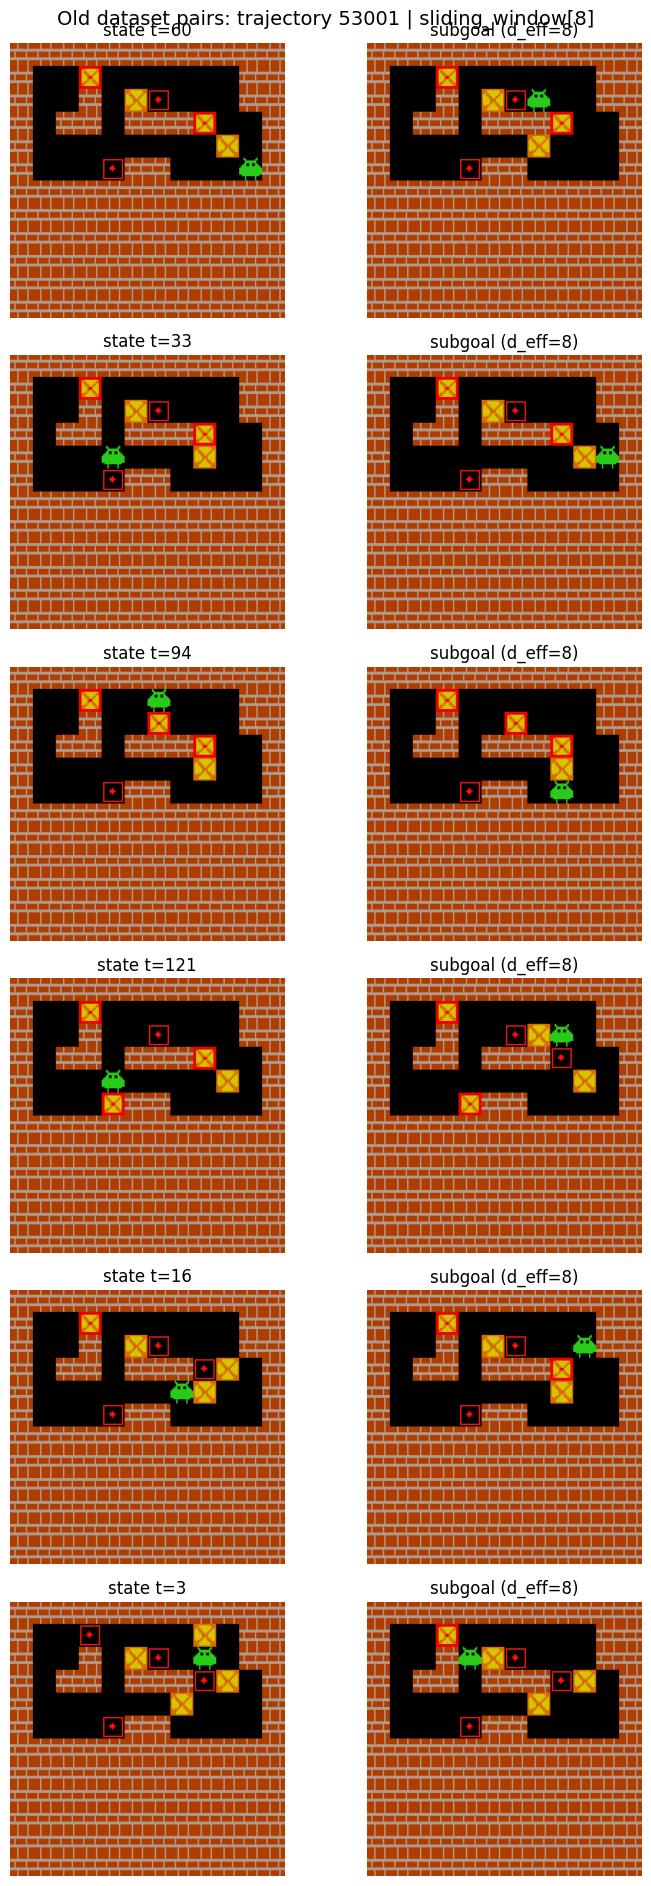

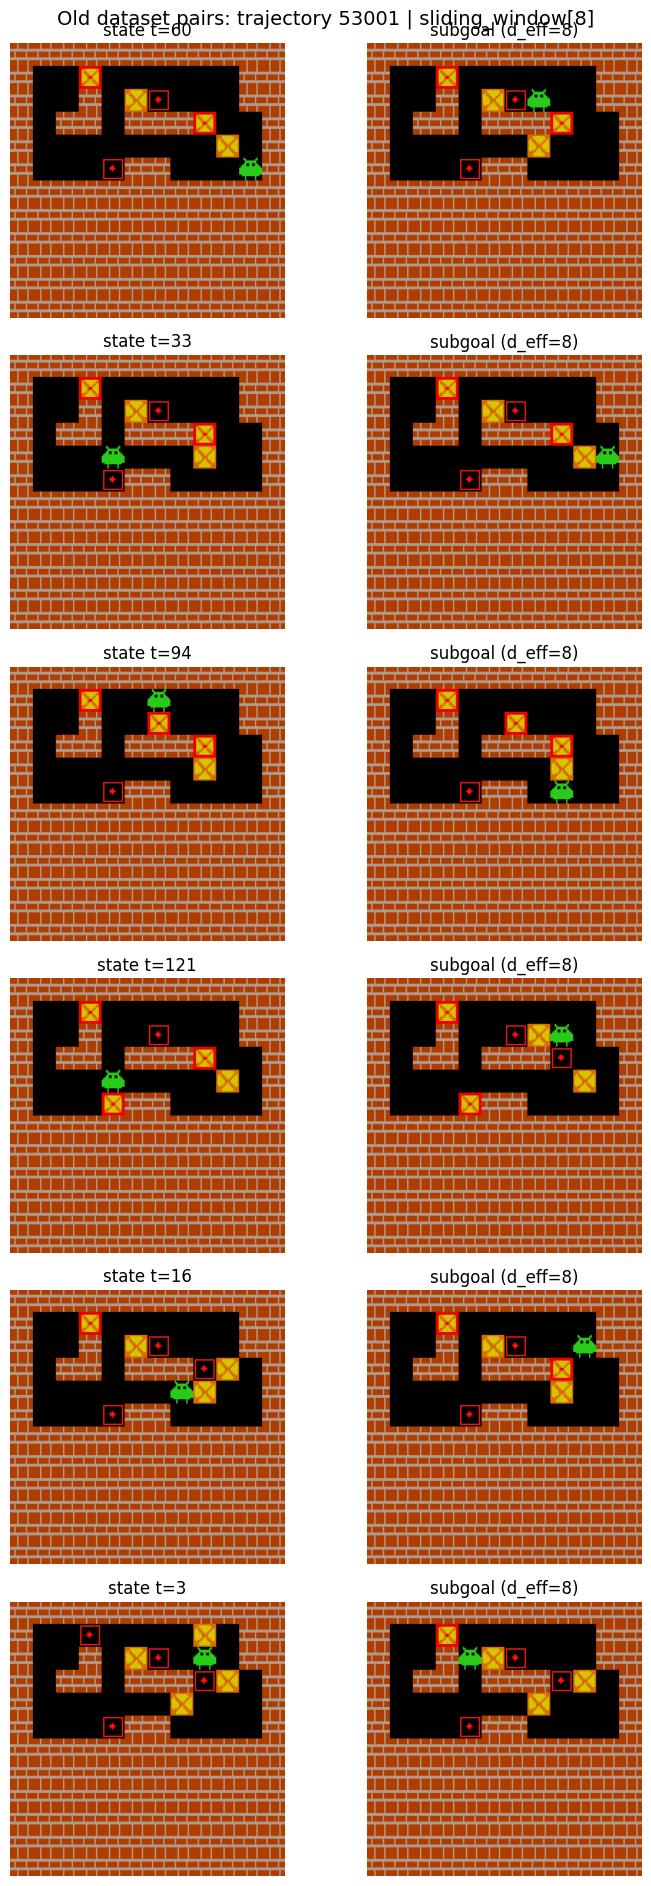

In [5]:
# Pick a reasonably long trajectory for visualization.
offline_items = list(offline.items())
old_key, old_traj = max(offline_items[:30], key=lambda kv: len(kv[1]))
old_rows = old_generator_pairs_from_trajectory(old_traj, distance_range=OLD_DISTANCE_RANGE)

print('Selected trajectory key:', old_key)
print('Trajectory length:', len(old_traj))
print('Generated pairs (old sliding-window):', len(old_rows))
print('First 8 pair descriptors:')
for row in describe_rows(old_rows[:8]):
    print(' ', row)

fig, old_examples = plot_pair_rows(
    old_rows,
    env,
    title=f'Old dataset pairs: trajectory {old_key} | sliding_window{list(OLD_DISTANCE_RANGE)}',
    n=6,
    seed=3,
)
fig


## New way: experience-based hierarchical `k_offsets`

This uses the recent generator-target logic introduced for experiments in
`configs/offline_training/sokoban/sokoban_train_generator_signals.yaml`.

We extract solving paths from `Experience` objects and then create pairs centered on hierarchical subgoal positions where `k_used == 8`, using offsets `[-1, 1]`.


Selected solved experience index (within filtered list): 0
State path length: 224
Subgoal positions (first 20): [(0, 1), (1, 8), (9, 8), (17, 8), (25, 1), (26, 8), (34, 4), (38, 8), (46, 4), (50, 8), (58, 8), (66, 8), (74, 8), (82, 8), (90, 8), (98, 8), (106, 8), (114, 8), (122, 8), (130, 8)]
Generated pairs (k_offsets, k=8, offsets=[-1, 1]): 52
First 8 pair descriptors:
  {'start_index': 0, 'position': 9, 'offset': -1, 'k_used': 8}
  {'start_index': 2, 'position': 9, 'offset': 1, 'k_used': 8}
  {'start_index': 8, 'position': 17, 'offset': -1, 'k_used': 8}
  {'start_index': 10, 'position': 17, 'offset': 1, 'k_used': 8}
  {'start_index': 17, 'position': 26, 'offset': -1, 'k_used': 8}
  {'start_index': 19, 'position': 26, 'offset': 1, 'k_used': 8}
  {'start_index': 29, 'position': 38, 'offset': -1, 'k_used': 8}
  {'start_index': 31, 'position': 38, 'offset': 1, 'k_used': 8}


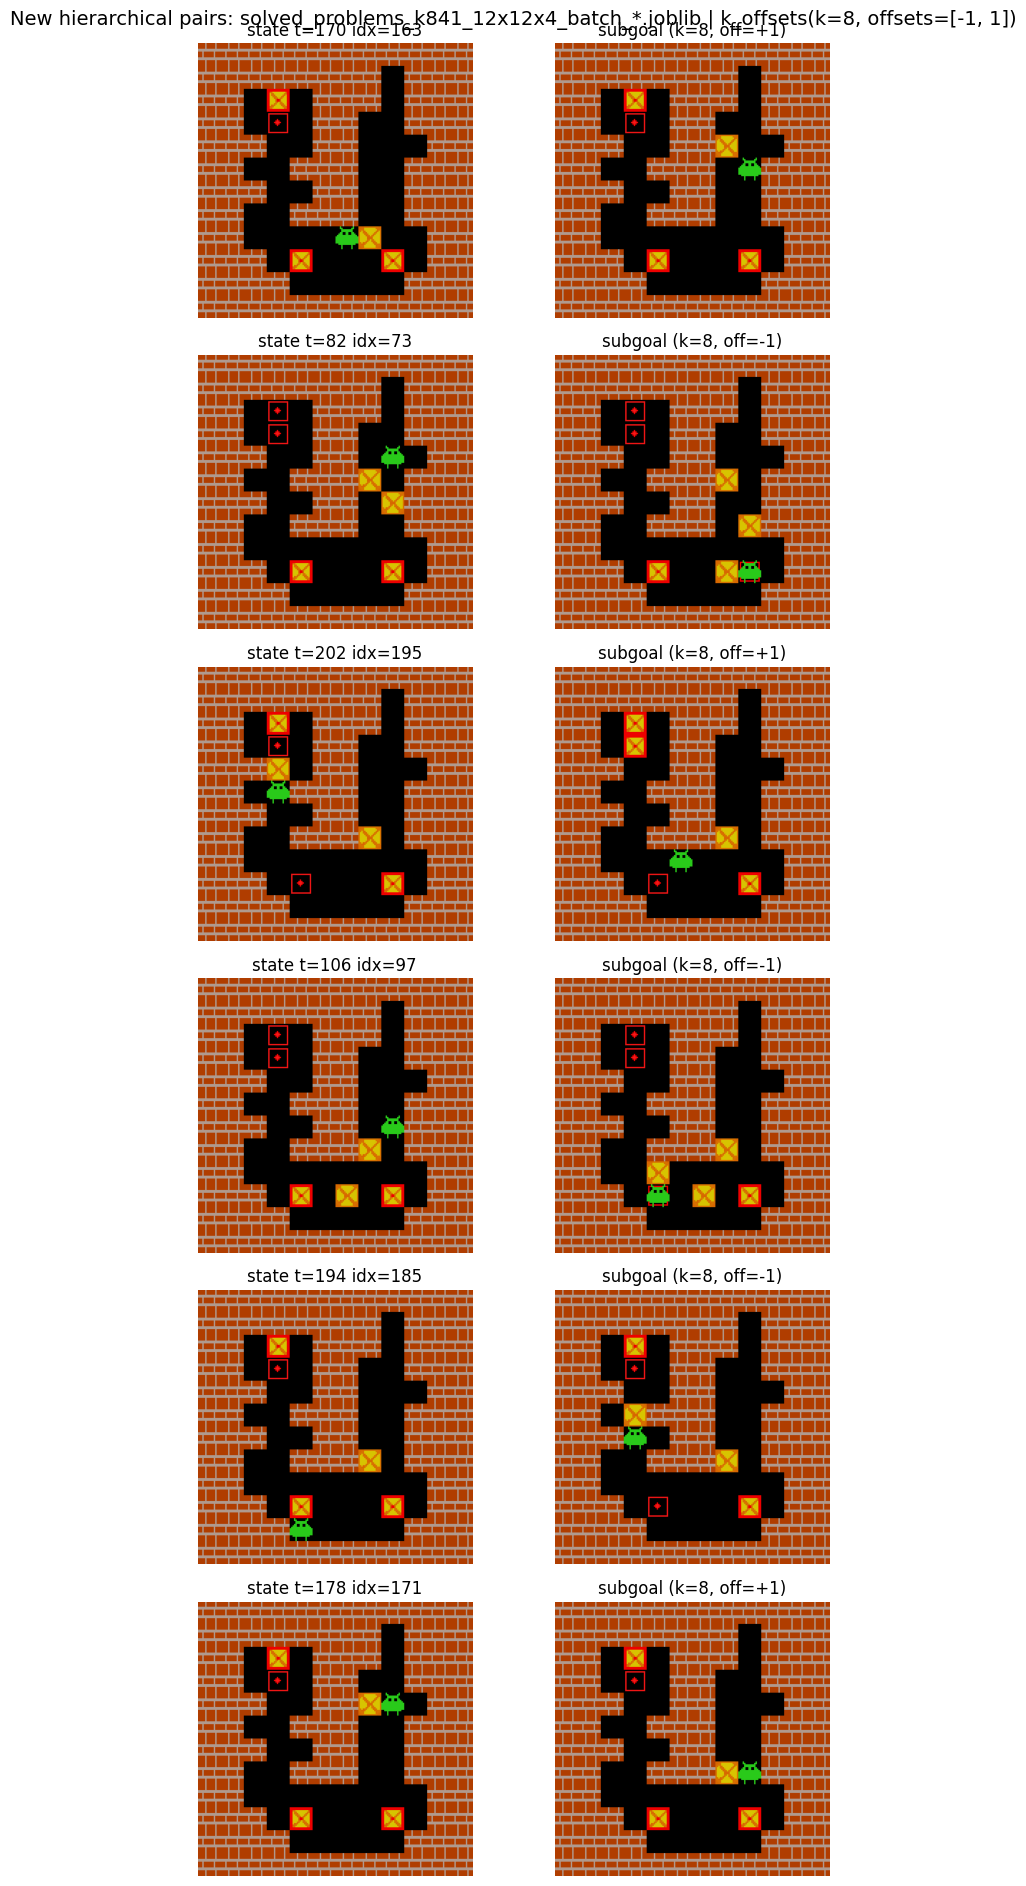

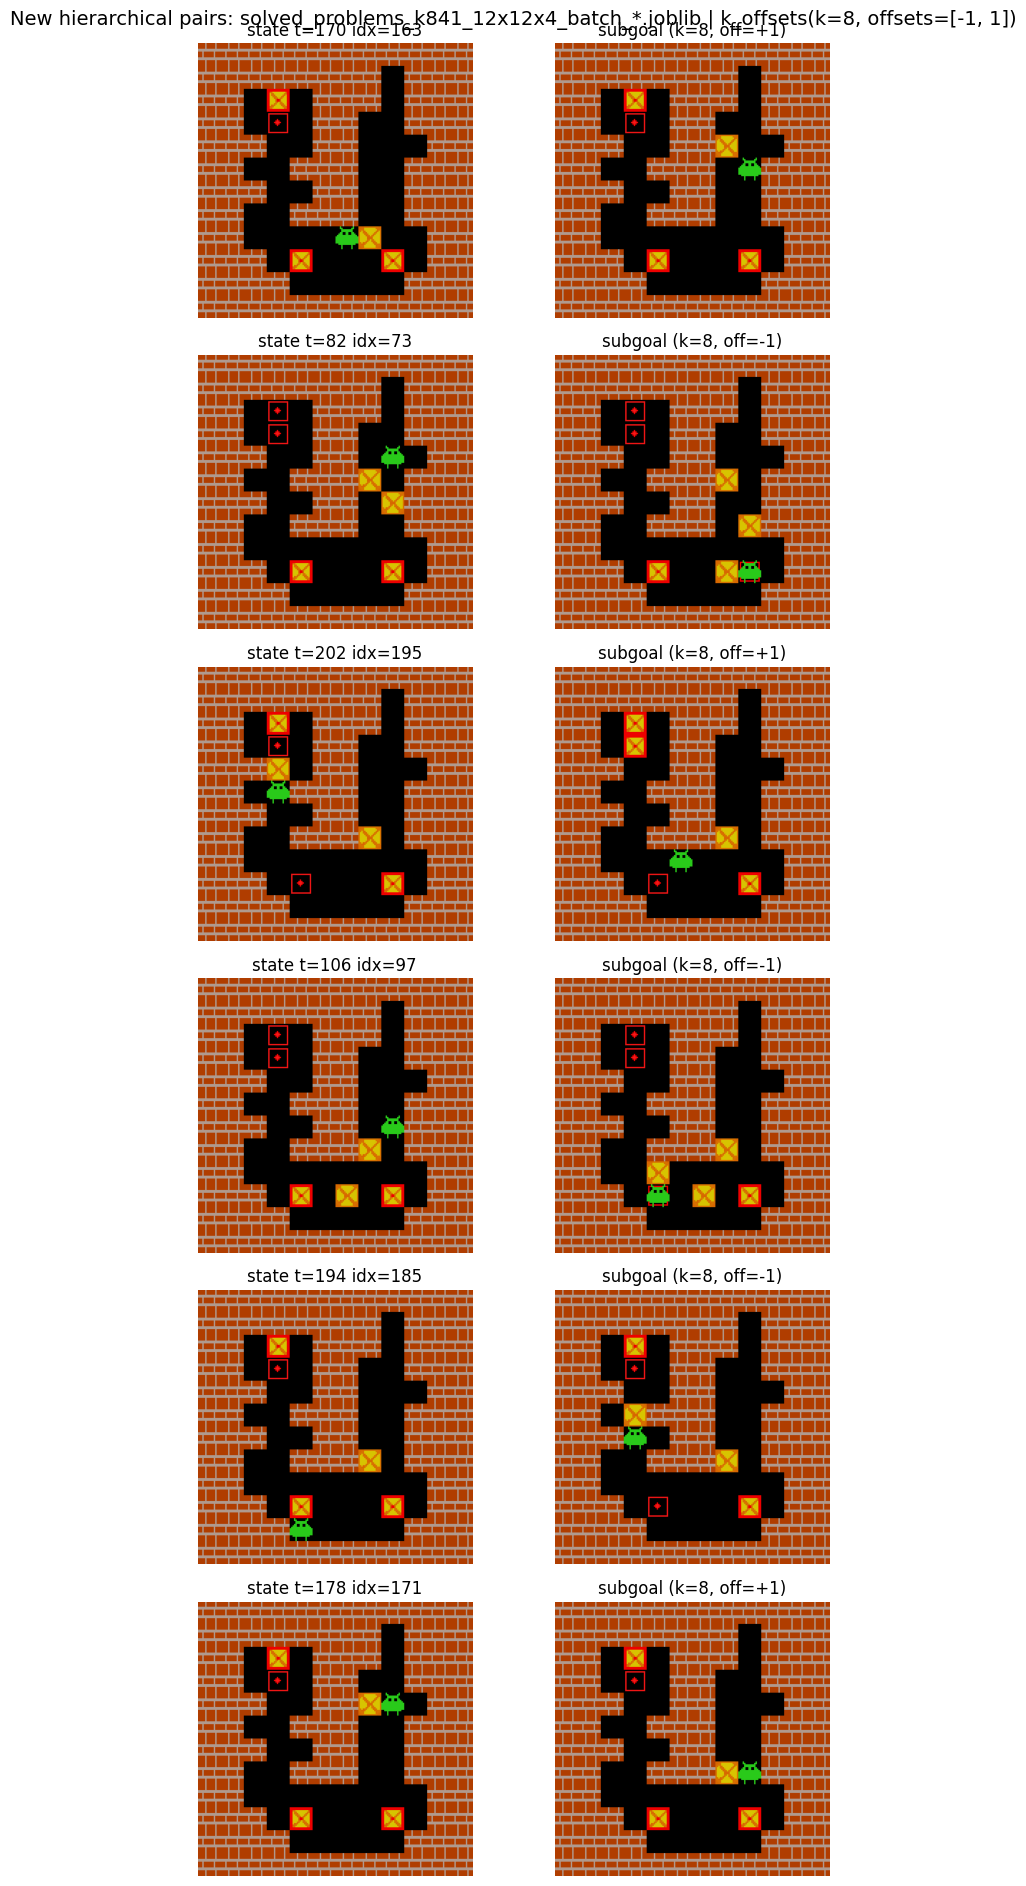

In [6]:
chosen_exp = None
chosen_rows = None
chosen_state_path = None
chosen_subgoal_positions = None
chosen_idx = None

for idx, exp in enumerate(exps):
    rows, state_path, subgoal_positions = k_offset_pairs_from_experience(exp, env, k=K, offsets=OFFSETS)
    if rows:
        chosen_exp = exp
        chosen_rows = rows
        chosen_state_path = state_path
        chosen_subgoal_positions = subgoal_positions
        chosen_idx = idx
        break

assert chosen_exp is not None, f'No experience with k={K} pairs found for pattern {EXP_PATTERN}'

print('Selected solved experience index (within filtered list):', chosen_idx)
print('State path length:', len(chosen_state_path))
print('Subgoal positions (first 20):', chosen_subgoal_positions[:20])
print(f'Generated pairs (k_offsets, k={K}, offsets={list(OFFSETS)}):', len(chosen_rows))
print('First 8 pair descriptors:')
for row in describe_rows(chosen_rows[:8], keys=('start_index', 'position', 'offset', 'k_used')):
    print(' ', row)

fig, new_examples = plot_pair_rows(
    chosen_rows,
    env,
    title=f'New hierarchical pairs: {EXP_PATTERN} | k_offsets(k={K}, offsets={list(OFFSETS)})',
    n=min(6, len(chosen_rows)),
    seed=5,
)
fig


## Pair-count comparison (signal density)

This compares how many training pairs each example produces under different schemes:

- old trajectory dataset + `sliding_window([8])`
- experience-based hierarchical `k_offsets(k=8, offsets=[-1,1])`
- experience-based `sliding_window(all pairs)` (also present in `sokoban_train_generator_signals.yaml` and typically much denser)


Old dataset trajectories + sliding_window([8]): {'n': 40, 'min': 18, 'mean': 56.88, 'median': 49.5, 'max': 139}
New experiences + k_offsets(k=8, offsets=[-1, 1]): {'n': 40, 'min': 3, 'mean': 10.95, 'median': 8.0, 'max': 52}
Experiences + sliding_window(all pairs): {'n': 40, 'min': 190, 'mean': 2061.2, 'median': 861.0, 'max': 24976}


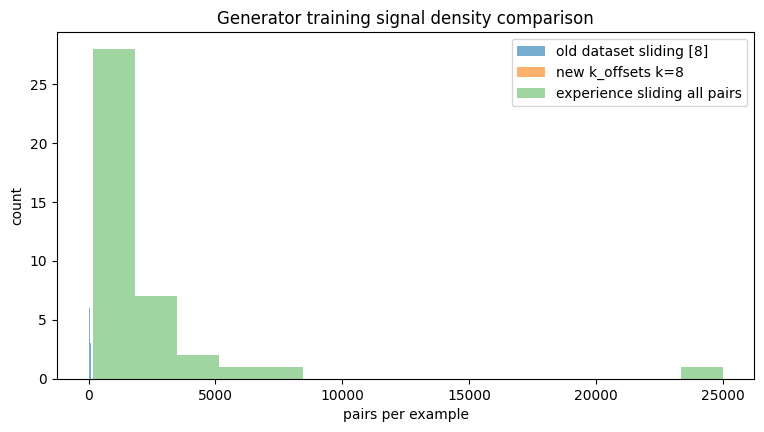

In [7]:
# Old config style: dataset trajectories + sliding [8]
old_counts = []
for traj in list(offline.values())[:40]:
    if len(traj) <= 1:
        continue
    old_counts.append(len(list(iter_state_pairs_sliding_window(traj, OLD_DISTANCE_RANGE))))

# New config style: experiences + hierarchical k_offsets
new_k_counts = []
exp_all_pair_counts = []
for exp in exps[:40]:
    state_path = state_path_from_experience(exp, env)
    if not state_path:
        continue
    subgoal_positions = _subgoal_positions_with_k(exp.search_info.solving_node, exp.solution.subgoal_distance_path)
    new_k_counts.append(len(list(iter_state_pairs_k_offsets(state_path, subgoal_positions, K, OFFSETS))))
    exp_all_pair_counts.append(len(list(iter_state_pairs_sliding_window(state_path, None))))

print('Old dataset trajectories + sliding_window([8]):', summarize_counts(old_counts))
print(f'New experiences + k_offsets(k={K}, offsets={list(OFFSETS)}):', summarize_counts(new_k_counts))
print('Experiences + sliding_window(all pairs):', summarize_counts(exp_all_pair_counts))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(old_counts, bins=15, alpha=0.6, label='old dataset sliding [8]')
ax.hist(new_k_counts, bins=15, alpha=0.6, label=f'new k_offsets k={K}')
ax.hist(exp_all_pair_counts, bins=15, alpha=0.45, label='experience sliding all pairs')
ax.set_xlabel('pairs per example')
ax.set_ylabel('count')
ax.set_title('Generator training signal density comparison')
ax.legend()
plt.show()
